# Understanding convolution:
- CNN learns better filters from data.

In [1]:
import numpy as np

# A convolution on a simple image matrix
- Stride = 1, padding =0

In [2]:
image = np.array([
    [1,1,1,0,0],
    [0,1,1,1,0],
    [0,0,1,1,1],
    [0,0,1,1,0],
    [0,1,1,0,0]
])

kernel = np.array([
    [1,0,1],
    [0,1,0],
    [1,0,1]
])

In [3]:

def convolve2d(image, kernel, stride=1, padding=0):
    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Output dimensions
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w))

    # Convolution
    for i in range(0, out_h):
        for j in range(0, out_w):
            region = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(region * kernel)

    return output


In [4]:
result = convolve2d(image, kernel, stride=1, padding=0)
print(result)

[[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]


# Now lets test this on an actual image

# 1. Load Image

In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("image_house.jpg")  # put your image path here

# Convert BGR → RGB (for display)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Plot all images

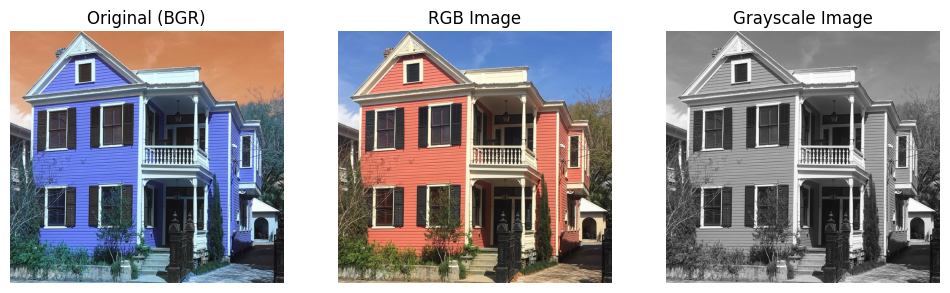

In [35]:
plt.figure(figsize=(12,4))

# Original (BGR - will look weird)
plt.subplot(1,3,1)
plt.title("Original (BGR)")
plt.imshow(image)
plt.axis('off')

# Correct RGB
plt.subplot(1,3,2)
plt.title("RGB Image")
plt.imshow(image_rgb)
plt.axis('off')

# Grayscale
plt.subplot(1,3,3)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.show()


# 2. Define Convolution Function

In [ ]:
def convolve2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(region * kernel)

    return output


 # 3. Define Filter (Edge Detection)


In [36]:
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])



# 4. Apply Convolution

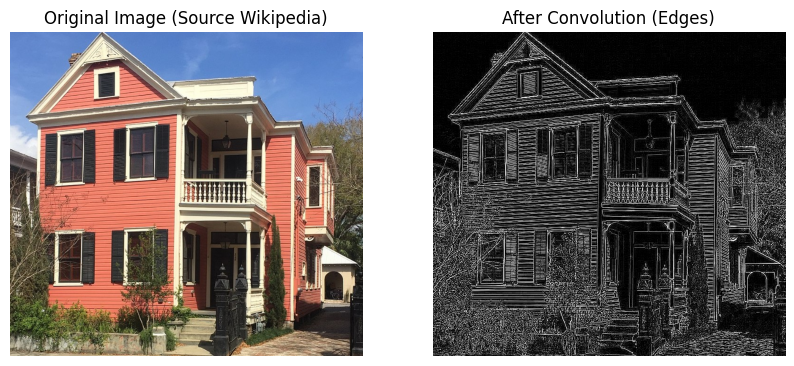

In [6]:
filtered = convolve2d(gray, kernel)

# Normalize for display
filtered = np.clip(filtered, 0, 255)

# -----------------------------
# 5. Display Results
# -----------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image (Source Wikipedia)")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Convolution (Edges)")
plt.imshow(filtered, cmap='gray')
plt.axis("off")

plt.show()


# Now lets apply different filters on same image

## step1: Try different filters

In [25]:
# Sobel filter for vertical edges
# kernel = np.array([
#     [-1,0,1],
#     [-2,0,2],
#     [-1,0,1]
# ])


# Sobel filter for horizontal edges
# kernel = np.array([
#     [-1,-2,-1],
#     [ 0, 0, 0],
#     [ 1, 2, 1]
# ])

# diagonal filter: Detects edges from top-left → bottom-right
# kernel = np.array([
#     [ 2, -1, -1],
#     [-1,  2, -1],
#     [-1, -1,  2]
# ])

# diagonal filter: Detects edges from top-right → bottom-left
kernel = np.array([
    [-1, -1,  2],
    [-1,  2, -1],
    [ 2, -1, -1]
])


# cirle: not effective heer
# kernel = np.array([
#     [ 1,  1,  1],
#     [ 1, -8,  1],
#     [ 1,  1,  1]
# ])


# blur filter
# kernel = np.ones((3,3)) / 9 

# sharpen filter
# kernel = np.array([
#     [0, -1, 0],
#     [-1, 5,-1],
#     [0, -1, 0]
# ])


# Emboss Filter :Gives 3D "engraved" effect
# Output looks like: Pencil carving + Raised surface
# kernel = np.array([
#     [-2, -1, 0],
#     [-1,  1, 1],
#     [ 0,  1, 2]
# ])




In [ ]:
## step2: Plot th e original with filtered image ( takes 20 secs)

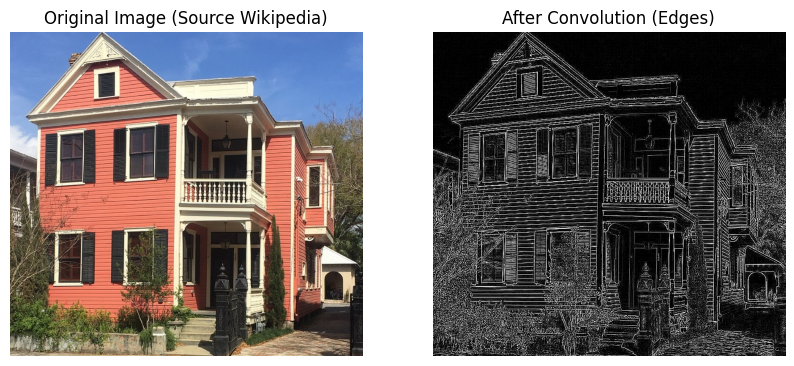

In [26]:
# Apply Convolution
filtered = convolve2d(gray, kernel)

# Normalize for display
filtered = np.clip(filtered, 0, 255)

# Display Results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image (Source Wikipedia)")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Convolution (Edges)")
plt.imshow(filtered, cmap='gray')
plt.axis("off")

plt.show()


# Put this in a loop

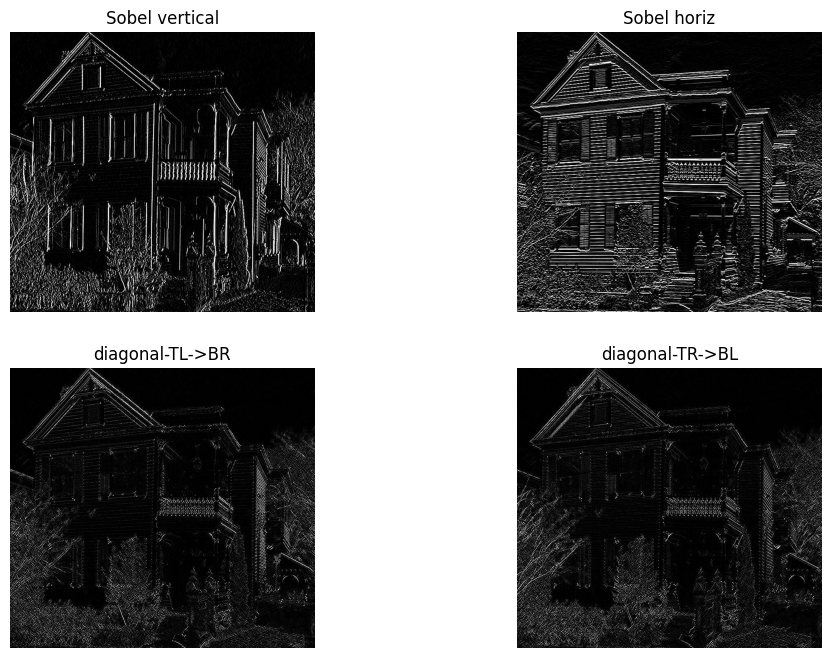

In [31]:
# Took 1 minutes
filters = {
    "Sobel vertical":  np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
    "Sobel horiz"  :   np.array([ [-1,-2,-1],[ 0, 0, 0], [ 1, 2, 1]]),
    "diagonal-TL->BR": np.array([[ 2, -1, -1],[-1,  2, -1], [-1, -1,  2]]),
    "diagonal-TR->BL": np.array([[-1, -1,  2],[-1,  2, -1], [ 2, -1, -1]]),
}

plt.figure(figsize=(12,8))

i = 1
for name, kernel in filters.items():
    filtered = convolve2d(gray, kernel)

    # Normalize for display
    filtered = np.clip(filtered, 0, 255)
   
    plt.subplot(2,2,i)
    plt.title(name)
    plt.imshow(filtered, cmap='gray')
    plt.axis('off')
    i += 1

plt.show()


# Doing above using tensorflow
- CNN learns better filters from data.


1/1 [==============================] - 0s 139ms/step


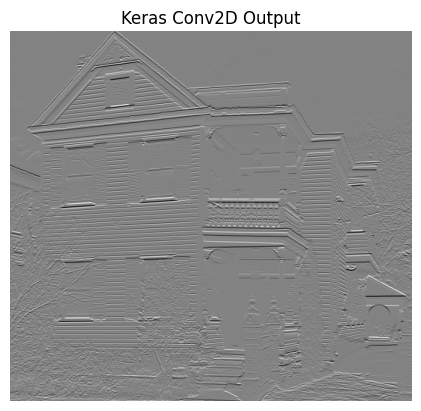

In [33]:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.models import Sequential


import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("image_house.jpg", cv2.IMREAD_GRAYSCALE)
image = image / 255.0  # normalize

# Add batch + channel dimensions
image_tf = tf.convert_to_tensor(image, dtype=tf.float32)
image_tf = tf.expand_dims(image_tf, axis=0)  # batch
image_tf = tf.expand_dims(image_tf, axis=-1) # channel

model = Sequential([
    Conv2D(
        filters=1,
        kernel_size=(3,3),
        strides=(1,1),
        padding='valid',
        use_bias=False,
        input_shape=(None, None, 1)
    )
])

# Manually set weights (your horizontal filter)
kernel = np.array([
    [-1,-1,-1],
    [ 0, 0, 0],
    [ 1, 1, 1]
], dtype=np.float32)

kernel = kernel.reshape((3,3,1,1))
model.layers[0].set_weights([kernel])

# Predict
output = model.predict(image_tf)
output = np.squeeze(output)

plt.imshow(output, cmap='gray')
plt.title("Keras Conv2D Output")
plt.axis('off')
plt.show()
